In [824]:
import numpy as np
import yfinance as yf
import pandas as pd
from datetime import date

In [825]:
# Assets for the portfolio

tickers = [
    "SPY",   # S&P 500 ETF
    "AAPL",  # Apple
    "NVDA",  # Nvidia
    "MSFT",  # Microsoft
    "JPM",   # JPMorgan Chase
    "BAC",   # Bank of America
    "SHEL",  # Shell
    "XOM",   # Exxon Mobil
    "GLD",   # SPDR Gold Shares
    "BZ=F",  # Brent crude oil futures
    "NG=F"   # Natural gas (Henry Hub) futures
]


# Time period
START_DATE = "2010-01-01"
END_DATE = date.today().strftime("%Y-%m-%d")



In [826]:
# Getting data from Yahoo Finance

data = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True,
    progress=False
)


In [827]:
data

Price            Close                                                 \
Ticker            AAPL        BAC        BZ=F         GLD         JPM   
Date                                                                    
2010-01-04    6.400961  11.977122   80.120003  109.800003   28.152376   
2010-01-05    6.412027  12.366440   80.589996  109.699997   28.697687   
2010-01-06    6.310036  12.511474   81.889999  111.510002   28.855371   
2010-01-07    6.298372  12.923691   81.510002  110.820000   29.426947   
2010-01-08    6.340244  12.809189   81.370003  111.370003   29.354673   
...                ...        ...         ...         ...         ...   
2026-09-18  336.130005  57.730000  103.870003  401.170013  349.670013   
2026-09-21  338.980011  57.959999  100.339996  398.380005  352.040009   
2026-09-22  339.750000  56.200001   99.250000  400.070007  340.000000   
2026-09-23  337.019989  56.000000  103.080002  392.880005  337.529999   
2026-09-24  335.920013  56.029999  106.599998  391.690002  338.559998   

Price                                                             ...  \
Ticker            MSFT   NG=F        NVDA       SHEL         SPY  ...   
Date                                                              ...   
2010-01-04   22.984232  5.884    0.422817  26.799494   84.368965  ...   
2010-01-05   22.991661  5.637    0.428992  26.829582   84.592285  ...   
2010-01-06   22.850569  6.009    0.431736  26.610374   84.651894  ...   
2010-01-07   22.612926  5.806    0.423275  26.481432   85.009178  ...   
2010-01-08   22.768879  5.749    0.424189  26.442741   85.292091  ...   
...                ...    ...         ...        ...         ...  ...   
2026-09-18  493.779999  2.912  222.270004  94.540001  761.690002  ...   
2026-09-21  501.609985  2.836  227.380005  93.269997  773.500000  ...   
2026-09-22  498.000000  2.965  228.869995  93.930000  773.380005  ...   
2026-09-23  500.589996  3.023  225.509995  95.410004  767.809998  ...   
2026-09-24  497.929993  3.297  224.580002  95.599998  767.179993  ...   

Price            Volume                                               \
Ticker              BAC     BZ=F         GLD         JPM        MSFT   
Date                                                                   
2010-01-04  180845200.0     97.0  16224100.0  35460500.0  38409100.0   
2010-01-05  209521300.0     97.0  14213100.0  41208300.0  49749600.0   
2010-01-06  205257900.0      7.0  24981900.0  27729000.0  58182400.0   
2010-01-07  320868400.0      7.0  13609800.0  44864700.0  50559700.0   
2010-01-08  220104700.0      7.0  15894600.0  33110100.0  51197400.0   
...                 ...      ...         ...         ...         ...   
2026-09-18   52483900.0  37226.0   9523900.0  18312400.0  39622300.0   
2026-09-21   33228100.0  36907.0   6411000.0   6414700.0  27959900.0   
2026-09-22   45137800.0  47365.0   6519900.0  11485600.0  21652800.0   
2026-09-23   36727800.0  51561.0   7547000.0   7068500.0  19445600.0   
2026-09-24   40972300.0  51561.0   6694400.0   6934300.0  16637200.0   

Price                                                                  
Ticker          NG=F         NVDA       SHEL          SPY         XOM  
Date                                                                   
2010-01-04   78858.0  800204000.0  1643003.0  118944600.0  27809100.0  
2010-01-05   99492.0  728648000.0  1718458.0  111579900.0  30174700.0  
2010-01-06  140611.0  649168000.0  3040554.0  116074400.0  35044700.0  
2010-01-07  135113.0  547792000.0  1033089.0  131091100.0  27192100.0  
2010-01-08  101153.0  478168000.0  1438017.0  126402800.0  24891800.0  
...              ...          ...        ...          ...         ...  
2026-09-18  162448.0  190287400.0  4588694.0   65395100.0  37640600.0  
2026-09-21  189440.0  109806100.0  4995734.0   50484700.0  15752500.0  
2026-09-22  176560.0   95746700.0  5967765.0   34802300.0         NaN  
2026-09-23  103189.0   89547300.0  5255050.0   54931700.0  12569300.0  
2026-09-2

In [828]:
# We only keep the Close values and we check dates order

data = data["Close"].sort_index()
data.tail()

Ticker,AAPL,BAC,BZ=F,GLD,JPM,MSFT,NG=F,NVDA,SHEL,SPY,XOM
Date,,,,,,,,,,,
2026-09-18,336.130005,57.730000,103.870003,401.170013,349.670013,493.779999,2.912,222.270004,94.540001,761.690002,163.539993
2026-09-21,338.980011,57.959999,100.339996,398.380005,352.040009,501.609985,2.836,227.380005,93.269997,773.500000,158.300003
2026-09-22,339.750000,56.200001,99.250000,400.070007,340.000000,498.000000,2.965,228.869995,93.930000,773.380005,NaN
2026-09-23,337.019989,56.000000,103.080002,392.880005,337.529999,500.589996,3.023,225.509995,95.410004,767.809998,161.229996
2026-09-24,335.920013,56.029999,106.599998,391.690002,338.559998,497.929993,3.297,224.580002,95.599998,767.179993,162.139999


In [829]:
data

Ticker,AAPL,BAC,BZ=F,GLD,JPM,MSFT,NG=F,NVDA,SHEL,SPY,XOM
Date,,,,,,,,,,,
2010-01-04,6.400961,11.977122,80.120003,109.800003,28.152376,22.984232,5.884,0.422817,26.799494,84.368965,37.136806
2010-01-05,6.412027,12.366440,80.589996,109.699997,28.697687,22.991661,5.637,0.428992,26.829582,84.592285,37.281822
2010-01-06,6.310036,12.511474,81.889999,111.510002,28.855371,22.850569,6.009,0.431736,26.610374,84.651894,37.604042
2010-01-07,6.298372,12.923691,81.510002,110.820000,29.426947,22.612926,5.806,0.423275,26.481432,85.009178,37.485886
2010-01-08,6.340244,12.809189,81.370003,111.370003,29.354673,22.768879,5.749,0.424189,26.442741,85.292091,37.335522
...,...,...,...,...,...,...,...,...,...,...,...
2026-09-18,336.130005,57.730000,103.870003,401.170013,349.670013,493.779999,2.912,222.270004,94.540001,761.690002,163.539993
2026-09-21,338.980011,57.959999,100.339996,398.380005,352.040009,501.609985,2.836,227.380005,93.269997,773.500000,158.300003
2026-09-22,339.750000,56.200001,99.250000,400.070007,340.000000,498.000000,2.965,228.869995,93.930000,773.380005,NaN


In [830]:
# Renaming the columns

data.rename(columns={
    
    "SPY": "S&P 500",
    "AAPL": "Apple",
    "NVDA": "Nvidia",
    "MSFT": "Microsoft",
    "JPM": "JPMorgan",
    "BAC": "Bank of America",
    "SHEL": "Shell",
    "XOM": "Exxon Mobil",
    "GLD": "Gold",
    "BZ=F": "Oil",
    "NG=F": "Gas"
    
},inplace = True)

In [831]:
data.head(10)

Ticker,Apple,Bank of America,Oil,Gold,JPMorgan,Microsoft,Gas,Nvidia,Shell,S&P 500,Exxon Mobil
Date,,,,,,,,,,,
2010-01-04,6.400961,11.977122,80.120003,109.800003,28.152376,22.984232,5.884,0.422817,26.799494,84.368965,37.136806
2010-01-05,6.412027,12.366440,80.589996,109.699997,28.697687,22.991661,5.637,0.428992,26.829582,84.592285,37.281822
2010-01-06,6.310036,12.511474,81.889999,111.510002,28.855371,22.850569,6.009,0.431736,26.610374,84.651894,37.604042
2010-01-07,6.298372,12.923691,81.510002,110.820000,29.426947,22.612926,5.806,0.423275,26.481432,85.009178,37.485886
2010-01-08,6.340244,12.809189,81.370003,111.370003,29.354673,22.768879,5.749,0.424189,26.442741,85.292091,37.335522
2010-01-11,6.284312,12.923691,80.970001,112.849998,29.256121,22.479254,5.454,0.418244,26.855375,85.411194,37.754421
2010-01-12,6.212827,12.488574,79.300003,110.489998,28.572861,22.330721,5.591,0.404066,26.249321,84.614647,37.566444
2010-01-13,6.300463,12.687050,78.309998,111.540001,29.072184,22.538668,5.733,0.409554,26.266512,85.329330,37.416077
2010-01-14,6.263974,12.839724,77.820000,112.029999,29.361254,22.991661,5.588,0.403151,26.202038,85.560097,37.421440


In [832]:
# Getting NaN number
data.isna().sum()

Ticker
Apple               3
Bank of America     3
Oil                34
Gold                3
JPMorgan            3
Microsoft           3
Gas                 2
Nvidia              3
Shell               3
S&P 500             3
Exxon Mobil         4
dtype: int64

In [833]:
# Removing NaN values
data.dropna(inplace=True)
data.isna().sum()

Ticker
Apple              0
Bank of America    0
Oil                0
Gold               0
JPMorgan           0
Microsoft          0
Gas                0
Nvidia             0
Shell              0
S&P 500            0
Exxon Mobil        0
dtype: int64

In [834]:
data.columns

Index(['Apple', 'Bank of America', 'Oil', 'Gold', 'JPMorgan', 'Microsoft',
       'Gas', 'Nvidia', 'Shell', 'S&P 500', 'Exxon Mobil'],
      dtype='object', name='Ticker')

In [835]:
# Changing columns order

column = ["S&P 500", "Nvidia", "Apple", "Microsoft", "JPMorgan", "Bank of America", "Exxon Mobil", "Shell", "Gold", "Oil", "Gas" ]
data = data[column]

In [836]:
data

Ticker,S&P 500,Nvidia,Apple,Microsoft,JPMorgan,Bank of America,Exxon Mobil,Shell,Gold,Oil,Gas
Date,,,,,,,,,,,
2010-01-04,84.368965,0.422817,6.400961,22.984232,28.152376,11.977122,37.136806,26.799494,109.800003,80.120003,5.884
2010-01-05,84.592285,0.428992,6.412027,22.991661,28.697687,12.366440,37.281822,26.829582,109.699997,80.589996,5.637
2010-01-06,84.651894,0.431736,6.310036,22.850569,28.855371,12.511474,37.604042,26.610374,111.510002,81.889999,6.009
2010-01-07,85.009178,0.423275,6.298372,22.612926,29.426947,12.923691,37.485886,26.481432,110.820000,81.510002,5.806
2010-01-08,85.292091,0.424189,6.340244,22.768879,29.354673,12.809189,37.335522,26.442741,111.370003,81.370003,5.749
...,...,...,...,...,...,...,...,...,...,...,...
2026-09-17,760.710999,219.339996,337.000000,497.750000,349.309998,58.180000,163.270004,95.820000,398.359985,104.820000,2.901
2026-09-18,761.690002,222.270004,336.130005,493.779999,349.670013,57.730000,163.539993,94.540001,401.170013,103.870003,2.912
2026-09-21,773.500000,227.380005,338.980011,501.609985,352.040009,57.959999,158.300003,93.269997,398.380005,100.339996,2.836


In [837]:
data.iloc[-1]

Ticker
S&P 500            767.179993
Nvidia             224.580002
Apple              335.920013
Microsoft          497.929993
JPMorgan           338.559998
Bank of America     56.029999
Exxon Mobil        162.139999
Shell               95.599998
Gold               391.690002
Oil                106.599998
Gas                  3.297000
Name: 2026-09-24 00:00:00, dtype: float64

In [838]:
# Creating the dataframe returns 
returns = data.pct_change().dropna()
returns

Ticker,S&P 500,Nvidia,Apple,Microsoft,JPMorgan,Bank of America,Exxon Mobil,Shell,Gold,Oil,Gas
Date,,,,,,,,,,,
2010-01-05,0.002647,0.014603,0.001729,0.000323,0.019370,0.032505,0.003905,0.001123,-0.000911,0.005866,-0.041978
2010-01-06,0.000705,0.006397,-0.015906,-0.006137,0.005495,0.011728,0.008643,-0.008170,0.016500,0.016131,0.065993
2010-01-07,0.004221,-0.019597,-0.001848,-0.010400,0.019808,0.032947,-0.003142,-0.004846,-0.006188,-0.004640,-0.033783
2010-01-08,0.003328,0.002161,0.006648,0.006897,-0.002456,-0.008860,-0.004011,-0.001461,0.004963,-0.001718,-0.009817
2010-01-11,0.001396,-0.014016,-0.008822,-0.012720,-0.003357,0.008939,0.011220,0.015605,0.013289,-0.004916,-0.051313
...,...,...,...,...,...,...,...,...,...,...,...
2026-09-17,0.011339,0.025432,0.013808,0.015195,0.001118,0.004836,-0.000306,0.001254,0.016899,-0.009544,0.003459
2026-09-18,0.001287,0.013358,-0.002582,-0.007976,0.001031,-0.007735,0.001654,-0.013358,0.007054,-0.009063,0.003792
2026-09-21,0.015505,0.022990,0.008479,0.015857,0.006778,0.003984,-0.032041,-0.013434,-0.006955,-0.033985,-0.026099


In [839]:
# Creating the dataframe crash_days where we only keep days where the S&P returns are smaller than 3% 
crash_days = returns.loc[returns["S&P 500"]<=-0.03]
crash_days

Ticker,S&P 500,Nvidia,Apple,Microsoft,JPMorgan,Bank of America,Exxon Mobil,Shell,Gold,Oil,Gas
Date,,,,,,,,,,,
2010-02-04,-0.030866,-0.058057,-0.036039,-0.027593,-0.048151,-0.050226,-0.028228,-0.040719,-0.039834,-0.049921,-0.000554
2010-05-06,-0.033214,-0.020689,-0.038048,-0.029146,-0.042693,-0.071307,-0.034457,-0.034561,0.029542,-0.033652,-0.015535
2010-05-20,-0.037760,-0.023511,-0.042603,-0.040014,-0.039360,-0.061925,-0.033947,-0.017351,-0.006774,-0.025105,-0.012506
2010-06-04,-0.035137,-0.047244,-0.027212,-0.039837,-0.037852,-0.029096,-0.032976,-0.042175,0.010427,-0.044026,0.022814
2010-06-29,-0.030875,-0.055856,-0.045211,-0.041135,-0.038402,-0.043964,-0.020181,-0.031593,0.001487,-0.027710,-0.035828
2011-08-04,-0.046842,-0.095206,-0.038719,-0.036404,-0.049624,-0.074424,-0.049923,-0.070524,-0.005264,-0.052813,-0.036430
2011-08-08,-0.065123,-0.078764,-0.054627,-0.046729,-0.094149,-0.203182,-0.061882,-0.068168,0.033199,-0.051477,-0.001522
2011-08-10,-0.044178,-0.045630,-0.027593,-0.053948,-0.055769,-0.109210,-0.044119,-0.040357,0.035407,0.040070,0.002253
2011-08-18,-0.043119,-0.067915,-0.037825,-0.022970,-0.037736,-0.060322,-0.043420,-0.036077,0.018920,-0.032640,-0.010425


In [840]:
# On affiche le nombre de jours de crash, la plus petite / grande date, top 5 rendements les plus faibles

print(f"Number of crash days {len(crash_days)}")
print(f"Oldest crash day: {crash_days.index.min().date()}")
print(f"More recent crah day: {crash_days.index.max().date()}")
crash_days["S&P 500"].nsmallest(5)

Number of crash days 46
Oldest crash day: 2010-02-04
More recent crah day: 2025-04-10


Date
2020-03-16   -0.109424
2020-03-12   -0.095678
2020-03-09   -0.078094
2011-08-08   -0.065123
2025-04-04   -0.058543
Name: S&P 500, dtype: float64

In [841]:
crash_days

Ticker,S&P 500,Nvidia,Apple,Microsoft,JPMorgan,Bank of America,Exxon Mobil,Shell,Gold,Oil,Gas
Date,,,,,,,,,,,
2010-02-04,-0.030866,-0.058057,-0.036039,-0.027593,-0.048151,-0.050226,-0.028228,-0.040719,-0.039834,-0.049921,-0.000554
2010-05-06,-0.033214,-0.020689,-0.038048,-0.029146,-0.042693,-0.071307,-0.034457,-0.034561,0.029542,-0.033652,-0.015535
2010-05-20,-0.037760,-0.023511,-0.042603,-0.040014,-0.039360,-0.061925,-0.033947,-0.017351,-0.006774,-0.025105,-0.012506
2010-06-04,-0.035137,-0.047244,-0.027212,-0.039837,-0.037852,-0.029096,-0.032976,-0.042175,0.010427,-0.044026,0.022814
2010-06-29,-0.030875,-0.055856,-0.045211,-0.041135,-0.038402,-0.043964,-0.020181,-0.031593,0.001487,-0.027710,-0.035828
2011-08-04,-0.046842,-0.095206,-0.038719,-0.036404,-0.049624,-0.074424,-0.049923,-0.070524,-0.005264,-0.052813,-0.036430
2011-08-08,-0.065123,-0.078764,-0.054627,-0.046729,-0.094149,-0.203182,-0.061882,-0.068168,0.033199,-0.051477,-0.001522
2011-08-10,-0.044178,-0.045630,-0.027593,-0.053948,-0.055769,-0.109210,-0.044119,-0.040357,0.035407,0.040070,0.002253
2011-08-18,-0.043119,-0.067915,-0.037825,-0.022970,-0.037736,-0.060322,-0.043420,-0.036077,0.018920,-0.032640,-0.010425


In [842]:
# on calcule ensuite coefficients régression

import statsmodels.api as sm

results = []

benchmark = "S&P 500"
for asset in crash_days.columns:

    if asset == benchmark:
        continue

    y = crash_days[asset]
    X = crash_days[benchmark]

    X = sm.add_constant(X)

    model = sm.OLS(y,X).fit()

    results.append(
    {
        "Asset": asset,
        "alpha": model.params["const"],
        "crash_beta":model.params[benchmark],
        "std_error": model.bse[benchmark],
        "t_stat":model.tvalues[benchmark],
        "p_value":model.pvalues[benchmark],
        "r_squared":model.rsquared,
        "n_crash_days":int(model.nobs),
    }
    )




In [843]:
results

[{'Asset': 'Nvidia',
  'alpha': np.float64(-0.022377683056999987),
  'crash_beta': np.float64(1.0586399045414747),
  'std_error': np.float64(0.19519120020403835),
  't_stat': np.float64(5.423604667807009),
  'p_value': np.float64(2.354057095195947e-06),
  'r_squared': np.float64(0.4006714190317483),
  'n_crash_days': 46},
 {'Asset': 'Apple',
  'alpha': np.float64(-0.0066672349217467295),
  'crash_beta': np.float64(0.9516439156324349),
  'std_error': np.float64(0.13907368096392936),
  't_stat': np.float64(6.842731917617516),
  'p_value': np.float64(1.9444216307996815e-08),
  'r_squared': np.float64(0.5155411113651289),
  'n_crash_days': 46},
 {'Asset': 'Microsoft',
  'alpha': np.float64(-0.004075884151815512),
  'crash_beta': np.float64(0.9492928536498763),
  'std_error': np.float64(0.1292047974363967),
  't_stat': np.float64(7.347195092482399),
  'p_value': np.float64(3.5531400256606683e-09),
  'r_squared': np.float64(0.5509346079286008),
  'n_crash_days': 46},
 {'Asset': 'JPMorgan',
 

In [844]:
crash_betas = pd.DataFrame(results)
crash_betas

,Asset,alpha,crash_beta,std_error,t_stat,p_value,r_squared,n_crash_days
0,Nvidia,-0.022378,1.058640,0.195191,5.423605,2.354057e-06,0.400671,46
1,Apple,-0.006667,0.951644,0.139074,6.842732,1.944422e-08,0.515541,46
2,Microsoft,-0.004076,0.949293,0.129205,7.347195,3.553140e-09,0.550935,46
3,JPMorgan,0.014479,1.465005,0.160353,9.136135,1.004381e-11,0.654818,46
4,Bank of America,0.014414,1.696670,0.241266,7.032368,1.024908e-08,0.529181,46
5,Exxon Mobil,0.011551,1.271887,0.167942,7.573389,1.665926e-09,0.565888,46
6,Shell,0.039655,1.982105,0.262100,7.562392,1.728277e-09,0.565173,46
7,Gold,0.008246,0.201451,0.166082,1.212960,2.316171e-01,0.032356,46
8,Oil,0.019846,1.385903,0.481814,2.876428,6.179991e-03,0.158279,46
9,Gas,-0.015001,0.002467,0.300445,0.008211,9.934856e-01,0.000002,46


In [845]:
#Defining portfolio weight

weight_Nvidia = 0.15
weight_Apple = 0.15
weight_Microsoft = 0.15
weight_JPMorgan = 0.10
weight_Bank_of_America = 0.10
weight_Exxon_Mobil = 0.05
weight_Shell = 0.05
weight_Gold = 0.1
weight_Oil = 0.1 
weight_Gas = 0.05

s = weight_Nvidia + weight_Apple + weight_Microsoft + weight_JPMorgan + weight_Bank_of_America  + weight_Exxon_Mobil + weight_Shell + weight_Gold + weight_Oil + weight_Gas 
print(s)

1.0


In [846]:
list(crash_betas["Asset"])

['Nvidia',
 'Apple',
 'Microsoft',
 'JPMorgan',
 'Bank of America',
 'Exxon Mobil',
 'Shell',
 'Gold',
 'Oil',
 'Gas']

In [847]:
dico = {
    "Asset":list(crash_betas["Asset"]),
    "Weight":[weight_Nvidia,
            weight_Apple, 
                weight_Microsoft,
                weight_JPMorgan,
                weight_Bank_of_America,
                weight_Exxon_Mobil, 
                weight_Shell,
                weight_Gold,
                weight_Oil,
                weight_Gas ]
}

In [848]:
weight = pd.DataFrame(dico)
weight

,Asset,Weight
0,Nvidia,0.15
1,Apple,0.15
2,Microsoft,0.15
3,JPMorgan,0.10
4,Bank of America,0.10
5,Exxon Mobil,0.05
6,Shell,0.05
7,Gold,0.10
8,Oil,0.10
9,Gas,0.05


In [849]:
portfolio = crash_betas[["Asset","crash_beta"]]
portfolio

,Asset,crash_beta
0,Nvidia,1.058640
1,Apple,0.951644
2,Microsoft,0.949293
3,JPMorgan,1.465005
4,Bank of America,1.696670
5,Exxon Mobil,1.271887
6,Shell,1.982105
7,Gold,0.201451
8,Oil,1.385903
9,Gas,0.002467


In [850]:
portfolio = pd.merge(portfolio,weight,on="Asset")
portfolio

,Asset,crash_beta,Weight
0,Nvidia,1.058640,0.15
1,Apple,0.951644,0.15
2,Microsoft,0.949293,0.15
3,JPMorgan,1.465005,0.10
4,Bank of America,1.696670,0.10
5,Exxon Mobil,1.271887,0.05
6,Shell,1.982105,0.05
7,Gold,0.201451,0.10
8,Oil,1.385903,0.10
9,Gas,0.002467,0.05


In [851]:
data.iloc[-1] # une series

Ticker
S&P 500            767.179993
Nvidia             224.580002
Apple              335.920013
Microsoft          497.929993
JPMorgan           338.559998
Bank of America     56.029999
Exxon Mobil        162.139999
Shell               95.599998
Gold               391.690002
Oil                106.599998
Gas                  3.297000
Name: 2026-09-24 00:00:00, dtype: float64

In [852]:
spot_price = data.tail(1) # un dataframe
spot_price

Ticker,S&P 500,Nvidia,Apple,Microsoft,JPMorgan,Bank of America,Exxon Mobil,Shell,Gold,Oil,Gas
Date,,,,,,,,,,,
2026-09-24,767.179993,224.580002,335.920013,497.929993,338.559998,56.029999,162.139999,95.599998,391.690002,106.599998,3.297


In [853]:
spot_price = data.tail(1).transpose()  # un dataframe
spot_price

Date,2026-09-24
Ticker,
S&P 500,767.179993
Nvidia,224.580002
Apple,335.920013
Microsoft,497.929993
JPMorgan,338.559998
Bank of America,56.029999
Exxon Mobil,162.139999
Shell,95.599998
Gold,391.690002


In [854]:
portfolio = pd.merge(portfolio,spot_price,left_on="Asset",right_on="Ticker")
portfolio

,Asset,crash_beta,Weight,2026-09-24 00:00:00
0,Nvidia,1.058640,0.15,224.580002
1,Apple,0.951644,0.15,335.920013
2,Microsoft,0.949293,0.15,497.929993
3,JPMorgan,1.465005,0.10,338.559998
4,Bank of America,1.696670,0.10,56.029999
5,Exxon Mobil,1.271887,0.05,162.139999
6,Shell,1.982105,0.05,95.599998
7,Gold,0.201451,0.10,391.690002
8,Oil,1.385903,0.10,106.599998
9,Gas,0.002467,0.05,3.297000


In [855]:
portfolio.columns
L=list(portfolio.columns)
L

['Asset', 'crash_beta', 'Weight', Timestamp('2026-09-24 00:00:00')]

In [856]:
Initial_capital = 1_000_000 
#portfolio["Position Value $"] = Initial_capital * portfolio["Weight"] * portfolio[L[-1]]
portfolio["Position Value $"] = Initial_capital * portfolio["Weight"] 
portfolio
print(sum(portfolio["Position Value $"]))
portfolio

1000000.0


,Asset,crash_beta,Weight,2026-09-24 00:00:00,Position Value $
0,Nvidia,1.058640,0.15,224.580002,150000.0
1,Apple,0.951644,0.15,335.920013,150000.0
2,Microsoft,0.949293,0.15,497.929993,150000.0
3,JPMorgan,1.465005,0.10,338.559998,100000.0
4,Bank of America,1.696670,0.10,56.029999,100000.0
5,Exxon Mobil,1.271887,0.05,162.139999,50000.0
6,Shell,1.982105,0.05,95.599998,50000.0
7,Gold,0.201451,0.10,391.690002,100000.0
8,Oil,1.385903,0.10,106.599998,100000.0
9,Gas,0.002467,0.05,3.297000,50000.0


In [857]:
portfolio["Asset Volume"] = portfolio["Position Value $"]/portfolio[L[-1]]
portfolio

,Asset,crash_beta,Weight,2026-09-24 00:00:00,Position Value $,Asset Volume
0,Nvidia,1.058640,0.15,224.580002,150000.0,667.913433
1,Apple,0.951644,0.15,335.920013,150000.0,446.534871
2,Microsoft,0.949293,0.15,497.929993,150000.0,301.247168
3,JPMorgan,1.465005,0.10,338.559998,100000.0,295.368622
4,Bank of America,1.696670,0.10,56.029999,100000.0,1784.758204
5,Exxon Mobil,1.271887,0.05,162.139999,50000.0,308.375479
6,Shell,1.982105,0.05,95.599998,50000.0,523.012561
7,Gold,0.201451,0.10,391.690002,100000.0,255.303938
8,Oil,1.385903,0.10,106.599998,100000.0,938.086317
9,Gas,0.002467,0.05,3.297000,50000.0,15165.302105


In [858]:
portfolio.rename(columns={L[-1]:"Spot Price $"},inplace=True)
portfolio

,Asset,crash_beta,Weight,Spot Price $,Position Value $,Asset Volume
0,Nvidia,1.058640,0.15,224.580002,150000.0,667.913433
1,Apple,0.951644,0.15,335.920013,150000.0,446.534871
2,Microsoft,0.949293,0.15,497.929993,150000.0,301.247168
3,JPMorgan,1.465005,0.10,338.559998,100000.0,295.368622
4,Bank of America,1.696670,0.10,56.029999,100000.0,1784.758204
5,Exxon Mobil,1.271887,0.05,162.139999,50000.0,308.375479
6,Shell,1.982105,0.05,95.599998,50000.0,523.012561
7,Gold,0.201451,0.10,391.690002,100000.0,255.303938
8,Oil,1.385903,0.10,106.599998,100000.0,938.086317
9,Gas,0.002467,0.05,3.297000,50000.0,15165.302105


In [859]:
Shock = [-0.05,-0.1,-0.15,-0.2,-0.3,-0.4]

dico = {
    "S&P500 Shock":Shock,   
}

stress_results = pd.DataFrame(dico)
stress_results


,S&P500 Shock
0,-0.05
1,-0.10
2,-0.15
3,-0.20
4,-0.30
5,-0.40


In [860]:
for _, row in portfolio.iterrows():

    asset = row["Asset"]
    beta = row["crash_beta"]

    stressed_return = beta * stress_results["S&P500 Shock"]

    pnl = row["Position Value $"] * stressed_return

    stress_results[f"{asset} Stressed Return"] = stressed_return
    stress_results[f"{asset} PnL"] = pnl


stress_results

,S&P500 Shock,Nvidia Stressed Return,Nvidia PnL,Apple Stressed Return,Apple PnL,Microsoft Stressed Return,Microsoft PnL,JPMorgan Stressed Return,JPMorgan PnL,Bank of America Stressed Return,...,Exxon Mobil Stressed Return,Exxon Mobil PnL,Shell Stressed Return,Shell PnL,Gold Stressed Return,Gold PnL,Oil Stressed Return,Oil PnL,Gas Stressed Return,Gas PnL
0,-0.05,-0.052932,-7939.799284,-0.047582,-7137.329367,-0.047465,-7119.696402,-0.073250,-7325.022707,-0.084833,...,-0.063594,-3179.716657,-0.099105,-4955.261773,-0.010073,-1007.255013,-0.069295,-6929.514193,-0.000123,-6.167573
1,-0.10,-0.105864,-15879.598568,-0.095164,-14274.658734,-0.094929,-14239.392805,-0.146500,-14650.045415,-0.169667,...,-0.127189,-6359.433313,-0.198210,-9910.523546,-0.020145,-2014.510026,-0.138590,-13859.028387,-0.000247,-12.335145
2,-0.15,-0.158796,-23819.397852,-0.142747,-21411.988102,-0.142394,-21359.089207,-0.219751,-21975.068122,-0.254500,...,-0.190783,-9539.149970,-0.297316,-14865.785319,-0.030218,-3021.765039,-0.207885,-20788.542580,-0.000370,-18.502718
3,-0.20,-0.211728,-31759.197136,-0.190329,-28549.317469,-0.189859,-28478.785609,-0.293001,-29300.090830,-0.339334,...,-0.254377,-12718.866626,-0.396421,-19821.047092,-0.040290,-4029.020052,-0.277181,-27718.056774,-0.000493,-24.670291
4,-0.30,-0.317592,-47638.795704,-0.285493,-42823.976203,-0.284788,-42718.178414,-0.439501,-43950.136245,-0.509001,...,-0.381566,-19078.299939,-0.594631,-29731.570637,-0.060435,-6043.530078,-0.415771,-41577.085161,-0.000740,-37.005436
5,-0.40,-0.423456,-63518.394272,-0.380658,-57098.634938,-0.379717,-56957.571219,-0.586002,-58600.181660,-0.678668,...,-0.508755,-25437.733252,-0.792842,-39642.094183,-0.080580,-8058.040103,-0.554361,-55436.113548,-0.000987,-49.340582


In [861]:
L=[]
for name in stress_results.columns:
    if "PnL" in name:
        L.append(name)
print(L)

['Nvidia PnL', 'Apple PnL', 'Microsoft PnL', 'JPMorgan PnL', 'Bank of America PnL', 'Exxon Mobil PnL', 'Shell PnL', 'Gold PnL', 'Oil PnL', 'Gas PnL']


In [862]:
stress_results["Portfolio P&L $"] = stress_results[L].sum(axis=1) # somme sur chaque ligne
stress_results

,S&P500 Shock,Nvidia Stressed Return,Nvidia PnL,Apple Stressed Return,Apple PnL,Microsoft Stressed Return,Microsoft PnL,JPMorgan Stressed Return,JPMorgan PnL,Bank of America Stressed Return,...,Exxon Mobil PnL,Shell Stressed Return,Shell PnL,Gold Stressed Return,Gold PnL,Oil Stressed Return,Oil PnL,Gas Stressed Return,Gas PnL,Portfolio P&L $
0,-0.05,-0.052932,-7939.799284,-0.047582,-7137.329367,-0.047465,-7119.696402,-0.073250,-7325.022707,-0.084833,...,-3179.716657,-0.099105,-4955.261773,-0.010073,-1007.255013,-0.069295,-6929.514193,-0.000123,-6.167573,-54083.110998
1,-0.10,-0.105864,-15879.598568,-0.095164,-14274.658734,-0.094929,-14239.392805,-0.146500,-14650.045415,-0.169667,...,-6359.433313,-0.198210,-9910.523546,-0.020145,-2014.510026,-0.138590,-13859.028387,-0.000247,-12.335145,-108166.221996
2,-0.15,-0.158796,-23819.397852,-0.142747,-21411.988102,-0.142394,-21359.089207,-0.219751,-21975.068122,-0.254500,...,-9539.149970,-0.297316,-14865.785319,-0.030218,-3021.765039,-0.207885,-20788.542580,-0.000370,-18.502718,-162249.332993
3,-0.20,-0.211728,-31759.197136,-0.190329,-28549.317469,-0.189859,-28478.785609,-0.293001,-29300.090830,-0.339334,...,-12718.866626,-0.396421,-19821.047092,-0.040290,-4029.020052,-0.277181,-27718.056774,-0.000493,-24.670291,-216332.443991
4,-0.30,-0.317592,-47638.795704,-0.285493,-42823.976203,-0.284788,-42718.178414,-0.439501,-43950.136245,-0.509001,...,-19078.299939,-0.594631,-29731.570637,-0.060435,-6043.530078,-0.415771,-41577.085161,-0.000740,-37.005436,-324498.665987
5,-0.40,-0.423456,-63518.394272,-0.380658,-57098.634938,-0.379717,-56957.571219,-0.586002,-58600.181660,-0.678668,...,-25437.733252,-0.792842,-39642.094183,-0.080580,-8058.040103,-0.554361,-55436.113548,-0.000987,-49.340582,-432664.887983


In [863]:
stress_results["Portfolio Return"] = stress_results["Portfolio P&L $"]/Initial_capital
stress_results
stress_results.round(4)

,S&P500 Shock,Nvidia Stressed Return,Nvidia PnL,Apple Stressed Return,Apple PnL,Microsoft Stressed Return,Microsoft PnL,JPMorgan Stressed Return,JPMorgan PnL,Bank of America Stressed Return,...,Shell Stressed Return,Shell PnL,Gold Stressed Return,Gold PnL,Oil Stressed Return,Oil PnL,Gas Stressed Return,Gas PnL,Portfolio P&L $,Portfolio Return
0,-0.05,-0.0529,-7939.7993,-0.0476,-7137.3294,-0.0475,-7119.6964,-0.0733,-7325.0227,-0.0848,...,-0.0991,-4955.2618,-0.0101,-1007.2550,-0.0693,-6929.5142,-0.0001,-6.1676,-54083.111,-0.0541
1,-0.10,-0.1059,-15879.5986,-0.0952,-14274.6587,-0.0949,-14239.3928,-0.1465,-14650.0454,-0.1697,...,-0.1982,-9910.5235,-0.0201,-2014.5100,-0.1386,-13859.0284,-0.0002,-12.3351,-108166.222,-0.1082
2,-0.15,-0.1588,-23819.3979,-0.1427,-21411.9881,-0.1424,-21359.0892,-0.2198,-21975.0681,-0.2545,...,-0.2973,-14865.7853,-0.0302,-3021.7650,-0.2079,-20788.5426,-0.0004,-18.5027,-162249.333,-0.1622
3,-0.20,-0.2117,-31759.1971,-0.1903,-28549.3175,-0.1899,-28478.7856,-0.2930,-29300.0908,-0.3393,...,-0.3964,-19821.0471,-0.0403,-4029.0201,-0.2772,-27718.0568,-0.0005,-24.6703,-216332.444,-0.2163
4,-0.30,-0.3176,-47638.7957,-0.2855,-42823.9762,-0.2848,-42718.1784,-0.4395,-43950.1362,-0.5090,...,-0.5946,-29731.5706,-0.0604,-6043.5301,-0.4158,-41577.0852,-0.0007,-37.0054,-324498.666,-0.3245
5,-0.40,-0.4235,-63518.3943,-0.3807,-57098.6349,-0.3797,-56957.5712,-0.5860,-58600.1817,-0.6787,...,-0.7928,-39642.0942,-0.0806,-8058.0401,-0.5544,-55436.1135,-0.0010,-49.3406,-432664.888,-0.4327


In [864]:
summary = stress_results[["S&P500 Shock","Portfolio P&L $","Portfolio Return"]]

summary["S&P500 Shock"] = (summary["S&P500 Shock"].map("{:.0%}".format))
summary["Portfolio P&L $"] = (summary["Portfolio P&L $"].map("{:,.0f} $".format))
summary["Portfolio Return"] = (summary["Portfolio Return"].map("{:.2%}".format))
summary

C:\Users\antoi\AppData\Local\Temp\ipykernel_29176\4213438382.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary["S&P500 Shock"] = (summary["S&P500 Shock"].map("{:.0%}".format))
C:\Users\antoi\AppData\Local\Temp\ipykernel_29176\4213438382.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary["Portfolio P&L $"] = (summary["Portfolio P&L $"].map("{:,.0f} $".format))
C:\Users\antoi\AppData\Local\Temp\ipykernel_29176\4213438382.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy o

,S&P500 Shock,Portfolio P&L $,Portfolio Return
0,-5%,"-54,083 $",-5.41%
1,-10%,"-108,166 $",-10.82%
2,-15%,"-162,249 $",-16.22%
3,-20%,"-216,332 $",-21.63%
4,-30%,"-324,499 $",-32.45%
5,-40%,"-432,665 $",-43.27%


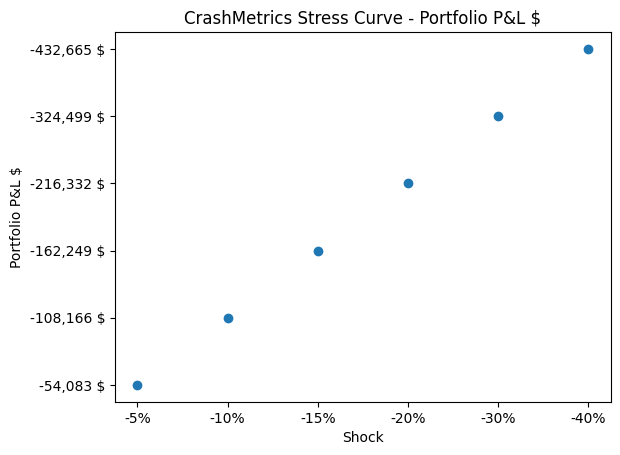

In [865]:
import matplotlib.pyplot as plt

plt.scatter(summary["S&P500 Shock"],summary["Portfolio P&L $"])
plt.xlabel("Shock")
plt.ylabel("Portfolio P&L $")
plt.title("CrashMetrics Stress Curve - Portfolio P&L $")
plt.show()

In [866]:
# We keeep a -10% scenario

scenario_10 = stress_results[stress_results["S&P500 Shock"]==-0.1]
scenario_10

pnl_contribution = []
for asset in list(crash_betas["Asset"]):
    pnl = scenario_10[f"{asset} PnL"].iloc[0]
    print(pnl)
    pnl_contribution.append(pnl)

dico = {
    "Asset": list(crash_betas["Asset"]),
    "P&L Contribution $": pnl_contribution

}

contribution = pd.DataFrame(dico)
contribution

-15879.598568122121
-14274.658734486524
-14239.392804748144
-14650.045414891605
-16966.696056421337
-6359.4333130050445
-9910.523545777092
-2014.510025869768
-13859.028386957203
-12.33514537670087


,Asset,P&L Contribution $
0,Nvidia,-15879.598568
1,Apple,-14274.658734
2,Microsoft,-14239.392805
3,JPMorgan,-14650.045415
4,Bank of America,-16966.696056
5,Exxon Mobil,-6359.433313
6,Shell,-9910.523546
7,Gold,-2014.510026
8,Oil,-13859.028387
9,Gas,-12.335145


In [867]:
contribution = contribution.sort_values("P&L Contribution $",ascending=True)
contribution

,Asset,P&L Contribution $
4,Bank of America,-16966.696056
0,Nvidia,-15879.598568
3,JPMorgan,-14650.045415
1,Apple,-14274.658734
2,Microsoft,-14239.392805
8,Oil,-13859.028387
6,Shell,-9910.523546
5,Exxon Mobil,-6359.433313
7,Gold,-2014.510026
9,Gas,-12.335145


In [868]:
contribution["P&L Contribution %"] = (contribution["P&L Contribution $"]/contribution["P&L Contribution $"].sum())*100
contribution

,Asset,P&L Contribution $,P&L Contribution %
4,Bank of America,-16966.696056,15.685762
0,Nvidia,-15879.598568,14.680737
3,JPMorgan,-14650.045415,13.544011
1,Apple,-14274.658734,13.196965
2,Microsoft,-14239.392805,13.164362
8,Oil,-13859.028387,12.812714
6,Shell,-9910.523546,9.162309
5,Exxon Mobil,-6359.433313,5.879315
7,Gold,-2014.510026,1.862421
9,Gas,-12.335145,0.011404


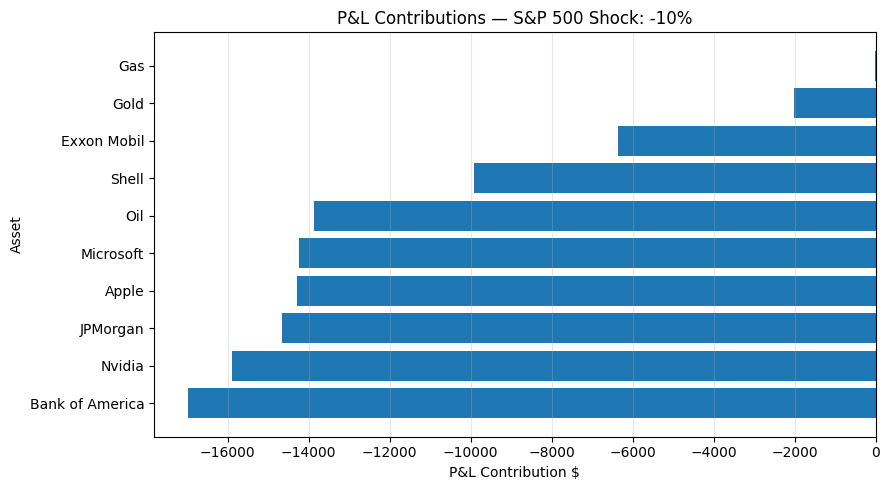

In [869]:
plt.figure(figsize=(9,5))
plt.barh(
    contribution["Asset"],
    contribution["P&L Contribution $"],
)
plt.title("P&L Contributions — S&P 500 Shock: -10%")
plt.xlabel("P&L Contribution $")
plt.ylabel("Asset")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


PARTIE HEDGE PROTECTIVE PUT

In [870]:
T = 0.5     # Maturity
r = 0.03    # risk free interest rate
sigma = 0.4 # implied volatility
N = 1000      # number of contracts

S0 = data["S&P 500"].iloc[-1]   # spot price

K = 0.9 * S0    # Strike
print(K)
print(S0)

690.4619934082032
767.1799926757812


In [871]:
# to justify implied vol
crash_days["S&P 500"].nsmallest(5).std() * np.sqrt(252)

np.float64(0.33557701899463005)

In [872]:
# Pricing the Put
from scipy.stats import norm

def put_black_scholes(S,K,r,sigma,T):
    d1 = (np.log(S/K)+(((1/2)*(sigma**2))+r)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    P = K*np.exp(-r*T)*norm.cdf(-d2) - norm.cdf(-d1)*S  
    P = P.round(2)

    return P

P = put_black_scholes(S0,K,r,sigma,T)
P

np.float64(45.09)

In [873]:
hedge_cost = N * P
print(hedge_cost)
print(f"Hedge cost as % of portfolio: {hedge_cost / 1_000_000}")



45090.0
Hedge cost as % of portfolio: 0.04509


In [874]:
# we then modify the amount of cash dedicated to assets
assets_capital = Initial_capital - hedge_cost
print(assets_capital)

# The new allocation follows this repartition
asset_scale = assets_capital / Initial_capital
print(asset_scale)


954910.0
0.95491


In [875]:
put_hedge = stress_results[["S&P500 Shock"]]
put_hedge["S&P500 Stressed Price $"] = S0 * (1 + put_hedge["S&P500 Shock"])
put_hedge

put_hedge["Put Price $"] = put_black_scholes(put_hedge["S&P500 Stressed Price $"],K,r,sigma,T-1/252)
put_hedge

put_hedge["P&L Put $"] = N * (put_hedge["Put Price $"] - P)
put_hedge

put_hedge = pd.merge(put_hedge,stress_results[["S&P500 Shock","Portfolio P&L $","Portfolio Return"]],left_on="S&P500 Shock",right_on="S&P500 Shock")
put_hedge


C:\Users\antoi\AppData\Local\Temp\ipykernel_29176\3195857311.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  put_hedge["S&P500 Stressed Price $"] = S0 * (1 + put_hedge["S&P500 Shock"])
C:\Users\antoi\AppData\Local\Temp\ipykernel_29176\3195857311.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  put_hedge["Put Price $"] = put_black_scholes(put_hedge["S&P500 Stressed Price $"],K,r,sigma,T-1/252)
C:\Users\antoi\AppData\Local\Temp\ipykernel_29176\3195857311.py:8: SettingWithCopyWarning: 
A value is trying

,S&P500 Shock,S&P500 Stressed Price $,Put Price $,P&L Put $,Portfolio P&L $,Portfolio Return
0,-0.05,728.820993,56.98,11890.0,-54083.110998,-0.054083
1,-0.10,690.461993,71.78,26690.0,-108166.221996,-0.108166
2,-0.15,652.102994,89.54,44450.0,-162249.332993,-0.162249
3,-0.20,613.743994,110.48,65390.0,-216332.443991,-0.216332
4,-0.30,537.025995,162.21,117120.0,-324498.665987,-0.324499
5,-0.40,460.307996,225.87,180780.0,-432664.887983,-0.432665


In [876]:
# We calculate the new Portfolio P&L because of the new asset allocation: juste P&L with assets 
put_hedge["Portfolio P&L new allocation $"] = put_hedge["Portfolio P&L $"] * asset_scale
put_hedge

# We calculate the new Portfolio Return because of the new asset allocation
#put_hedge["Portfolio Return"] = put_hedge["Portfolio Return"] * asset_scale

put_hedge["Portfolio P&L hedged $"] = put_hedge["Portfolio P&L new allocation $"] + put_hedge["P&L Put $"]
put_hedge

put_hedge["Portfolio Return hedged"] = put_hedge["Portfolio P&L hedged $"] / Initial_capital
put_hedge

,S&P500 Shock,S&P500 Stressed Price $,Put Price $,P&L Put $,Portfolio P&L $,Portfolio Return,Portfolio P&L new allocation $,Portfolio P&L hedged $,Portfolio Return hedged
0,-0.05,728.820993,56.98,11890.0,-54083.110998,-0.054083,-51644.503523,-39754.503523,-0.039755
1,-0.10,690.461993,71.78,26690.0,-108166.221996,-0.108166,-103289.007046,-76599.007046,-0.076599
2,-0.15,652.102994,89.54,44450.0,-162249.332993,-0.162249,-154933.510569,-110483.510569,-0.110484
3,-0.20,613.743994,110.48,65390.0,-216332.443991,-0.216332,-206578.014092,-141188.014092,-0.141188
4,-0.30,537.025995,162.21,117120.0,-324498.665987,-0.324499,-309867.021138,-192747.021138,-0.192747
5,-0.40,460.307996,225.87,180780.0,-432664.887983,-0.432665,-413156.028183,-232376.028183,-0.232376


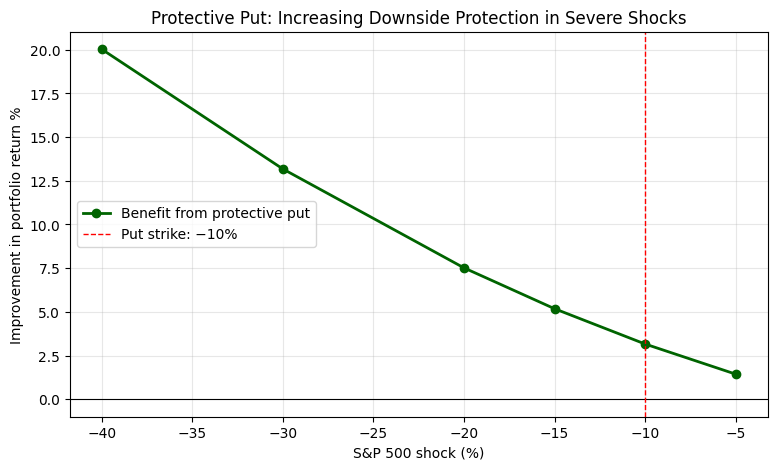

In [878]:
put_hedge["Hedge Benefit"] = (
    put_hedge["Portfolio Return hedged"]
    - put_hedge["Portfolio Return"]
)

plt.figure(figsize=(9, 5))

plt.plot(
    put_hedge["S&P500 Shock"] * 100,
    (put_hedge["Portfolio Return hedged"]- put_hedge["Portfolio Return"]) * 100,
    marker="o",
    linewidth=2,
    color="darkgreen",
    label="Benefit from protective put"
)

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(-10, color="red", linestyle="--", linewidth=1,label="Put strike: −10%")

plt.xlabel("S&P 500 shock (%)")
plt.ylabel("Improvement in portfolio return %")
plt.title("Protective Put: Increasing Downside Protection in Severe Shocks")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

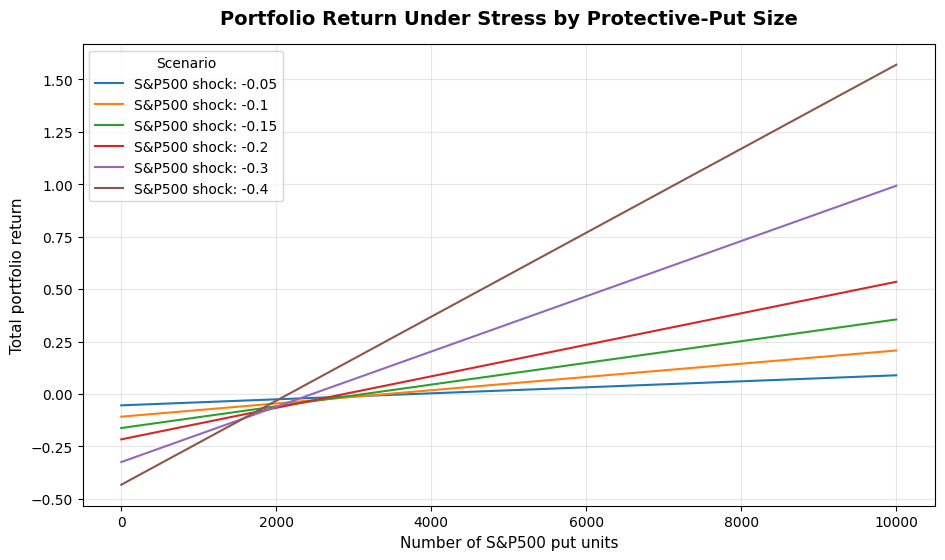

In [879]:
# put_hedge["Portfolio P&L new allocation $"] = put_hedge["Portfolio P&L $"] * asset_scale
# put_hedge

# assets_capital = Initial_capital - hedge_cost
# print(assets_capital)

# # The new allocation follows this repartition
# asset_scale = assets_capital / Initial_capital
# print(asset_scale)

X = np.linspace(0,10_000,1000)
plt.figure(figsize=(11, 6))

for _,row in put_hedge.iterrows():
    shock = row["S&P500 Shock"]
    Y = []
    for x in X:
        PnL_put = x * (row["Put Price $"] - P)
        hedge_cost = x*P # prix des puts
        assets_capital = Initial_capital - hedge_cost  # on change cash available pour asset
        asset_scale = assets_capital / Initial_capital # pourcentage de cash pour actif
        
        portfolio_PnL_new_allocation = row["Portfolio P&L $"]*asset_scale  # nouveau P&L du portefeuille sans put
        
        portfolio_PnL_hedged = portfolio_PnL_new_allocation + PnL_put  # P&L du portefeuille avec Put
        portfolio_return_hedged = portfolio_PnL_hedged / Initial_capital  # return portfolio
        Y.append(portfolio_return_hedged)

    plt.plot(X,Y,label=f"S&P500 shock: {shock}")


plt.legend(title="Scenario")

plt.xlabel("Number of S&P500 put units", fontsize=11)
plt.ylabel("Total portfolio return", fontsize=11)

plt.title(
    "Portfolio Return Under Stress by Protective-Put Size",
    fontsize=14,
    fontweight="bold",
    pad=14
)

plt.grid(alpha=0.30)
plt.show()
